In [8]:
import pandas as pd
from datetime import datetime

## Read training and test datasets

In [9]:
# helper function for reading datatset
def read_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d') # convert it to datatime

    return df

In [10]:
df_train = read_data('data/kospi_train.csv')
df_test = read_data('data/kospi_test.csv')

len(df_train), len(df_test)

(986, 244)

In [11]:
# the training dataset has daily KOSPI index from 2019 to 2022
df_train

,Date,Open,Low,High,Close,Volume
0,2019-01-02,2050.550049,2004.270020,2053.449951,2010.000000,326400
1,2019-01-03,2011.810059,1991.650024,2014.719971,1993.699951,428000
2,2019-01-04,1992.400024,1984.530029,2011.560059,2010.250000,409000
3,2019-01-07,2034.239990,2030.900024,2048.060059,2037.099976,440200
4,2019-01-08,2038.680054,2023.589966,2042.699951,2025.270020,397800
...,...,...,...,...,...,...
981,2022-12-23,2325.860107,2311.899902,2333.080078,2313.689941,367000
982,2022-12-26,2312.540039,2304.199951,2321.919922,2317.139893,427600
983,2022-12-27,2327.520020,2321.479980,2335.989990,2332.790039,448300
984,2022-12-28,2296.449951,2276.899902,2296.449951,2280.449951,405700


In [12]:
# the test dataset has daily KOSPI index in 2023
df_test

,Date,Open,Low,High,Close,Volume
0,2023-01-02,2249.949951,2222.370117,2259.879883,2225.669922,346100
1,2023-01-03,2230.979980,2180.669922,2230.979980,2218.679932,410000
2,2023-01-04,2205.979980,2198.820068,2260.060059,2255.979980,412700
3,2023-01-05,2268.199951,2252.969971,2281.389893,2264.649902,430800
4,2023-01-06,2253.399902,2253.270020,2300.620117,2289.969971,398300
...,...,...,...,...,...,...
239,2023-12-21,2598.370117,2587.159912,2610.810059,2600.020020,578300
240,2023-12-22,2617.719971,2599.510010,2621.370117,2599.510010,466000
241,2023-12-26,2609.439941,2594.649902,2612.139893,2602.590088,439500
242,2023-12-27,2599.350098,2590.080078,2613.500000,2613.500000,349700


## Part 1. Train regression models to predict the next day's `close` using `Open`, `Low`, `High`, `Close`, `Volume` of previous days as predictors using *only* df_train. Cross-validate to select the best model. Evaluate the accuracy of your model using `df_test`.


In [28]:
# import Setup for part 1
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

모든 모델을 훈련하고 평가합니다...

===== ElasticNet 모델 =====
ElasticNet Cross-Validation RMSE: 49.8044 (±18.1088)
Model: ElasticNet
Mean Squared Error: 641.2636
Mean Absolute Error: 19.4877
Root Mean Squared Error: 25.3232
R² Score: 0.9154

===== RandomForest 모델 =====
RandomForest Cross-Validation RMSE: 147.1486 (±116.4869)
Model: RandomForest
Mean Squared Error: 752.0217
Mean Absolute Error: 21.3613
Root Mean Squared Error: 27.4230
R² Score: 0.9008


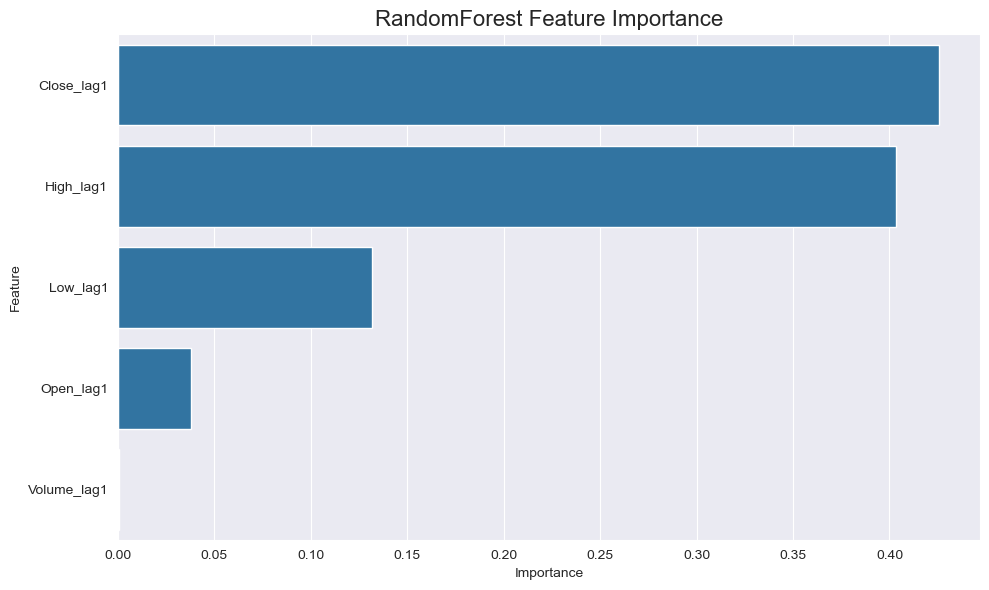


===== XGBoost 모델 =====
XGBoost Cross-Validation RMSE: 34.4674 (±4.2527)
Model: XGBoost
Mean Squared Error: 896.3202
Mean Absolute Error: 23.0451
Root Mean Squared Error: 29.9386
R² Score: 0.8818


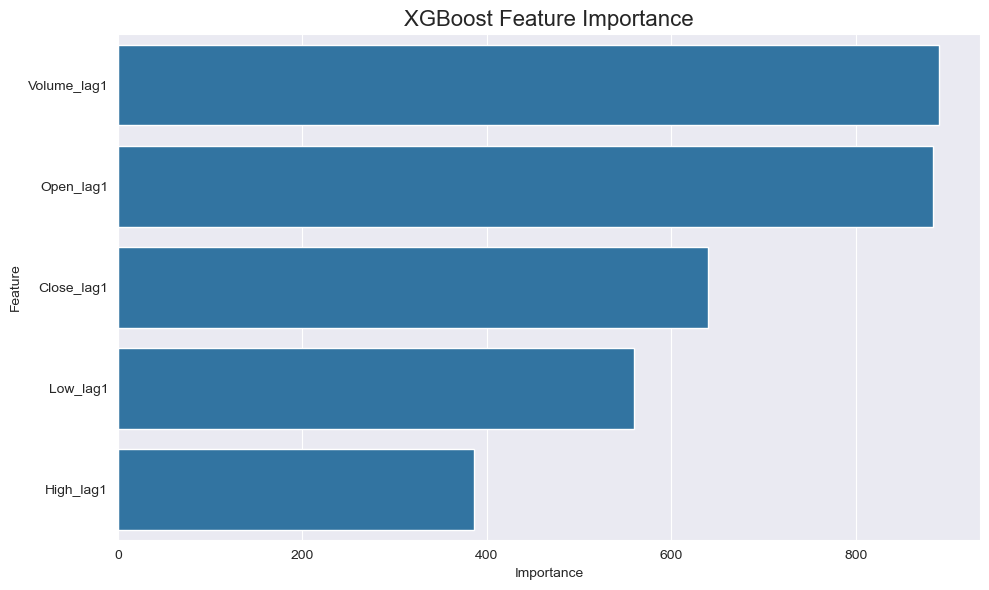


===== 모델 비교 =====
          Model         MSE        MAE       RMSE        R²
0    ElasticNet  641.263594  19.487701  25.323183  0.915445
1  RandomForest  752.021651  21.361331  27.423013  0.900841
2       XGBoost  896.320248  23.045129  29.938608  0.881814

최적 모델: ElasticNet (RMSE: 25.3232)


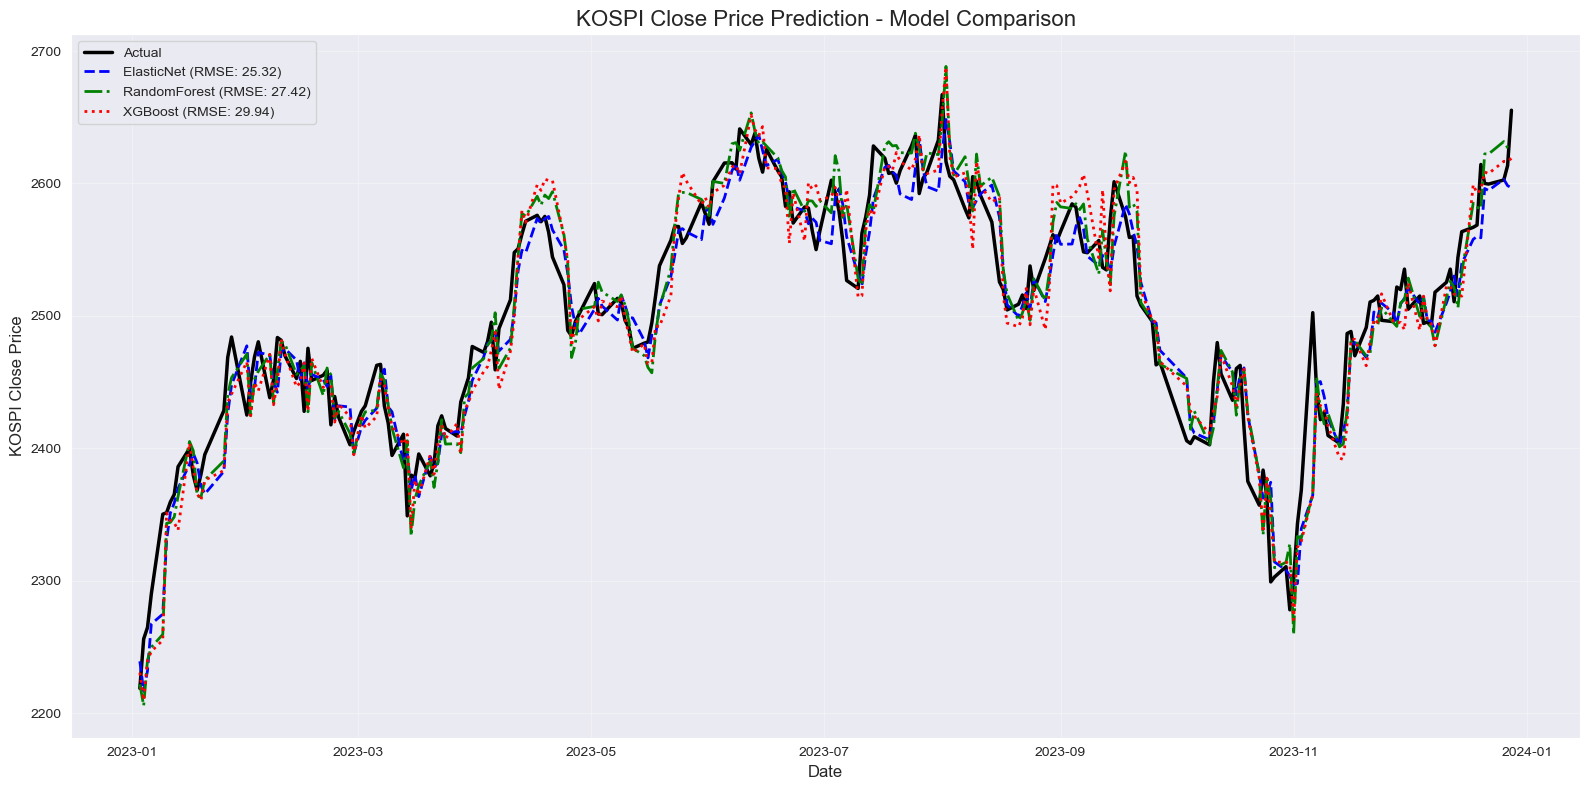

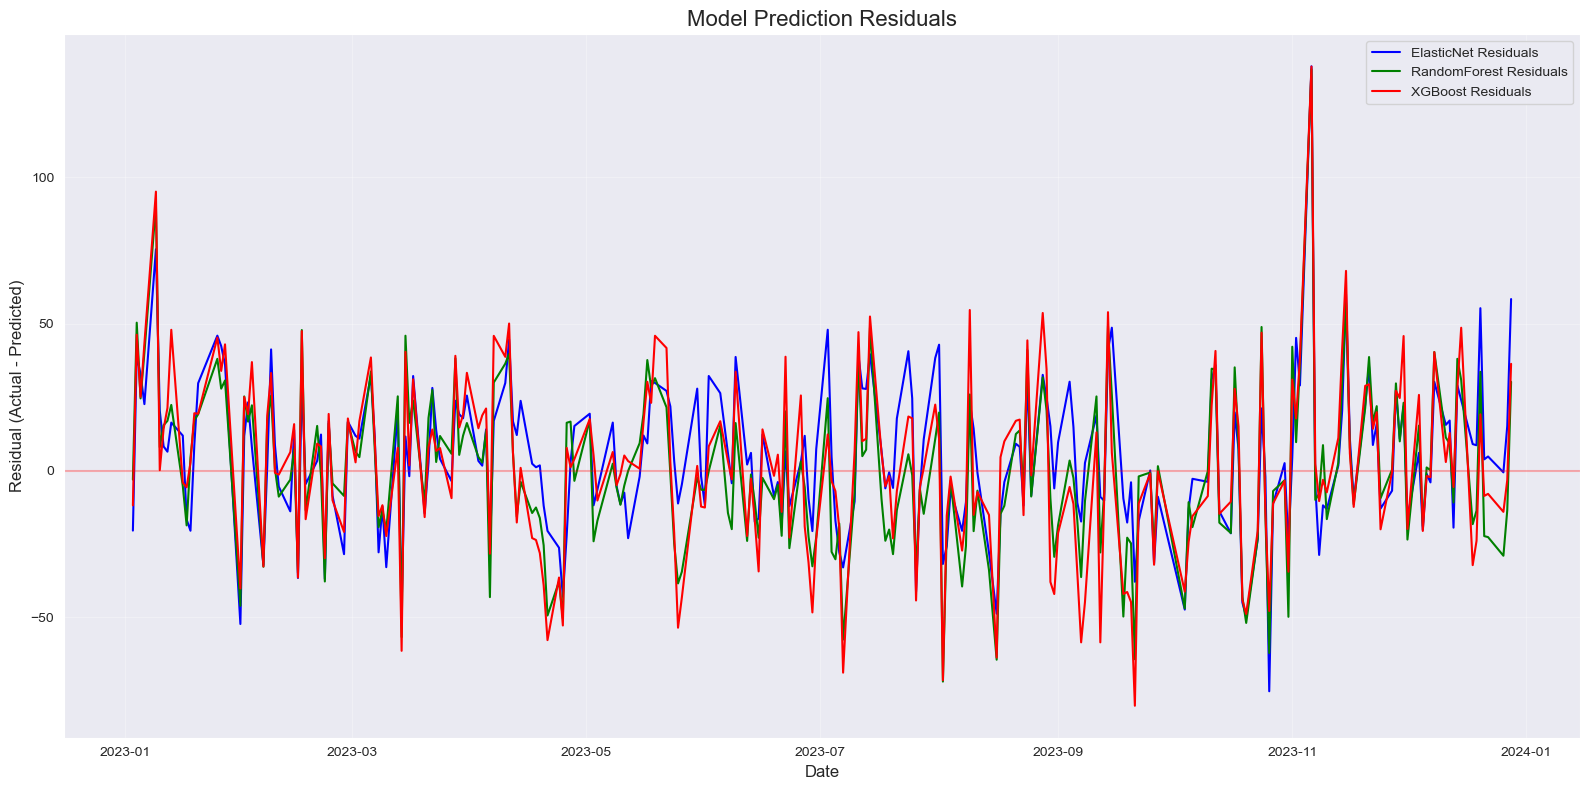

In [29]:
# Start Part 1

# 데이터 로드
def read_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')  # convert to datetime
    df.set_index('Date', inplace=True)  # Date를 인덱스로 설정
    return df

# 모델 평가 및 훈련 함수 수정 - 모든 모델 결과 반환
def train_and_evaluate_models(X_train, y_train, X_test, y_test, cv=5):
    """
    모든 모델을 훈련하고 평가하여 결과를 반환
    """
    results = {}
    tscv = TimeSeriesSplit(n_splits=cv)

    # 1. ElasticNet
    print("\n===== ElasticNet 모델 =====")
    elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
    try:
        # 교차 검증
        cv_scores = cross_val_score(elastic_model, X_train, y_train, cv=tscv, scoring='neg_mean_squared_error')
        cv_rmse = np.sqrt(-cv_scores)
        print(f"ElasticNet Cross-Validation RMSE: {cv_rmse.mean():.4f} (±{cv_rmse.std():.4f})")

        # 최종 모델 훈련
        elastic_model.fit(X_train, y_train)

        # 테스트 데이터 평가
        elastic_results = evaluate_model(elastic_model, X_test, y_test, "ElasticNet")
        results['ElasticNet'] = elastic_results
    except Exception as e:
        print(f"Error with ElasticNet: {e}")

    # 2. RandomForest
    print("\n===== RandomForest 모델 =====")
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    try:
        # 교차 검증
        cv_scores = cross_val_score(rf_model, X_train, y_train, cv=tscv, scoring='neg_mean_squared_error')
        cv_rmse = np.sqrt(-cv_scores)
        print(f"RandomForest Cross-Validation RMSE: {cv_rmse.mean():.4f} (±{cv_rmse.std():.4f})")

        # 최종 모델 훈련
        rf_model.fit(X_train, y_train)

        # 테스트 데이터 평가
        rf_results = evaluate_model(rf_model, X_test, y_test, "RandomForest")

        # 특성 중요도 시각화
        importances = rf_model.feature_importances_
        feature_importance = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)

        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_importance)
        plt.title('RandomForest Feature Importance', fontsize=16)
        plt.tight_layout()
        plt.savefig('feature_importance_RandomForest-part1.png', dpi=300)
        plt.show()

        results['RandomForest'] = rf_results
    except Exception as e:
        print(f"Error with RandomForest: {e}")

    # 3. XGBoost
    print("\n===== XGBoost 모델 =====")
    try:
        # DMatrix 형식으로 변환
        dtrain = xgb.DMatrix(X_train, label=y_train)
        dtest = xgb.DMatrix(X_test)

        # 파라미터 설정
        params = {
            'objective': 'reg:squarederror',
            'learning_rate': 0.1,
            'max_depth': 6,
            'seed': 42
        }

        # 교차 검증 수행
        cv_results = xgb.cv(
            params=params,
            dtrain=dtrain,
            num_boost_round=100,
            nfold=cv,
            metrics='rmse',
            seed=42
        )

        # 최종 RMSE 추출
        final_rmse = cv_results['test-rmse-mean'].iloc[-1]
        rmse_std = cv_results['test-rmse-std'].iloc[-1]
        print(f"XGBoost Cross-Validation RMSE: {final_rmse:.4f} (±{rmse_std:.4f})")

        # 최종 모델 훈련
        xgb_model = xgb.train(params, dtrain, num_boost_round=100)

        # 테스트 데이터 평가
        xgb_results = evaluate_xgboost_model(xgb_model, X_test, y_test)

        # 특성 중요도 시각화
        importance_scores = xgb_model.get_score(importance_type='weight')
        features = list(importance_scores.keys())
        scores = list(importance_scores.values())

        # DataFrame으로 변환
        feature_importance = pd.DataFrame({
            'Feature': features,
            'Importance': scores
        }).sort_values(by='Importance', ascending=False)

        # 시각화
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_importance)
        plt.title('XGBoost Feature Importance', fontsize=16)
        plt.tight_layout()
        plt.savefig('feature_importance_XGBoost-part1.png', dpi=300)
        plt.show()

        results['XGBoost'] = xgb_results
    except Exception as e:
        print(f"Error with XGBoost: {e}")

    # 모델 비교 및 최적 모델 선택
    if results:
        print("\n===== 모델 비교 =====")
        comparison_df = pd.DataFrame({
            'Model': [name for name in results.keys()],
            'MSE': [results[name]['mse'] for name in results.keys()],
            'MAE': [results[name]['mae'] for name in results.keys()],
            'RMSE': [results[name]['rmse'] for name in results.keys()],
            'R²': [results[name]['r2'] for name in results.keys()]
        })
        print(comparison_df)

        # 가장 낮은 RMSE를 가진 모델 찾기
        best_model_name = min(results, key=lambda x: results[x]['rmse'])
        print(f"\n최적 모델: {best_model_name} (RMSE: {results[best_model_name]['rmse']:.4f})")
    else:
        print("모든 모델 평가에 실패했습니다.")

    return results

# XGBoost 모델 평가 함수
def evaluate_xgboost_model(model, X_test, y_test):
    """
    XGBoost 모델 평가를 위한 함수
    """
    # DMatrix로 변환
    dtest = xgb.DMatrix(X_test)

    # 예측
    y_pred = model.predict(dtest)

    # 평가 지표 계산
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"Model: XGBoost")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

    return {
        'model_name': 'XGBoost',
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'predictions': y_pred
    }

# 일반 모델 평가 함수
def evaluate_model(model, X_test, y_test, model_name):
    """
    테스트 데이터에 대한 모델 성능 평가
    """
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"Model: {model_name}")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

    return {
        'model_name': model_name,
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'predictions': y_pred
    }

# 기능 함수들 - 원본 유지
def create_features(df, lag=1):
    """
    Create time series features based on lagged values.
    lag: Number of days to lag
    """
    df = df.copy()

    # Create lagged features
    for col in ['Open', 'Low', 'High', 'Close', 'Volume']:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

    # Drop rows with NaN values resulting from the lag
    df = df.dropna()

    return df

def prepare_data(df, target='Close'):
    """
    Prepare the data for training by creating features and target
    """
    # Feature columns (using yesterday's data to predict today)
    feature_cols = [col for col in df.columns if '_lag' in col]

    # Create X and y
    X = df[feature_cols]
    y = df[target]

    return X, y

# 결과 시각화 함수 - 모든 모델 비교
def plot_model_comparisons(df_test, y_test, model_results):
    """
    모든 모델 예측 결과를 한 그래프에 비교 시각화
    """
    test_dates = df_test.index

    plt.figure(figsize=(16, 8))

    # 실제 값 플롯
    plt.plot(test_dates, y_test.values, label='Actual', linewidth=2.5, color='black')

    # 각 모델의 예측값 플롯
    colors = ['blue', 'green', 'red']
    linestyles = ['--', '-.', ':']

    for i, (model_name, results) in enumerate(model_results.items()):
        plt.plot(test_dates, results['predictions'],
                 label=f"{model_name} (RMSE: {results['rmse']:.2f})",
                 linewidth=2,
                 color=colors[i % len(colors)],
                 linestyle=linestyles[i % len(linestyles)])

    plt.title('KOSPI Close Price Prediction - Model Comparison', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('KOSPI Close Price', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('kospi_prediction_comparison-part1.png', dpi=300)
    plt.show()

    # 오차(residual) 그래프도 추가
    plt.figure(figsize=(16, 8))

    for i, (model_name, results) in enumerate(model_results.items()):
        residuals = y_test.values - results['predictions']
        plt.plot(test_dates, residuals,
                 label=f"{model_name} Residuals",
                 linewidth=1.5,
                 color=colors[i % len(colors)])

    plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
    plt.title('Model Prediction Residuals', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Residual (Actual - Predicted)', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('kospi_prediction_residuals-part1.png', dpi=300)
    plt.show()

# 메인 실행 코드 수정
def run_part1():
    # 데이터 로드
    df_train = read_data('data/kospi_train.csv')
    df_test = read_data('data/kospi_test.csv')

    # 특성 생성
    df_train_features = create_features(df_train, lag=1)
    df_test_features = create_features(df_test, lag=1)

    # 훈련 데이터 준비
    X_train, y_train = prepare_data(df_train_features)
    X_test, y_test = prepare_data(df_test_features)

    # 특성 스케일링
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # DataFrame으로 변환
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

    # 모든 모델 훈련 및 평가
    print("모든 모델을 훈련하고 평가합니다...")
    model_results = train_and_evaluate_models(X_train_scaled, y_train, X_test_scaled, y_test)

    # 모델 시각화 비교
    if model_results:
        plot_model_comparisons(df_test_features, y_test, model_results)

    return model_results

# 이 코드를 실행하려면 이 파일을 직접 실행하세요
if __name__ == "__main__":
    # 코드 실행
    model_results = run_part1()

## Part 2. Extend the regression model by adding some extra features of your choice. You can use any statistics publicly available. 

In [30]:
# import Setup for part 1

import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import ElasticNet
import matplotlib.pyplot as plt
import seaborn as sns

Creating extended feature sets...
Shape of extended training features: (966, 37)
Number of features in Part 2: 37
Scaling features...
Using ElasticNet as the base model for extension...
Training the extended model...

Evaluating the extended model on the test set...
Model: Extended_ElasticNet
Mean Squared Error: 406.3182
Mean Absolute Error: 14.8543
Root Mean Squared Error: 20.1573
R² Score: 0.9350


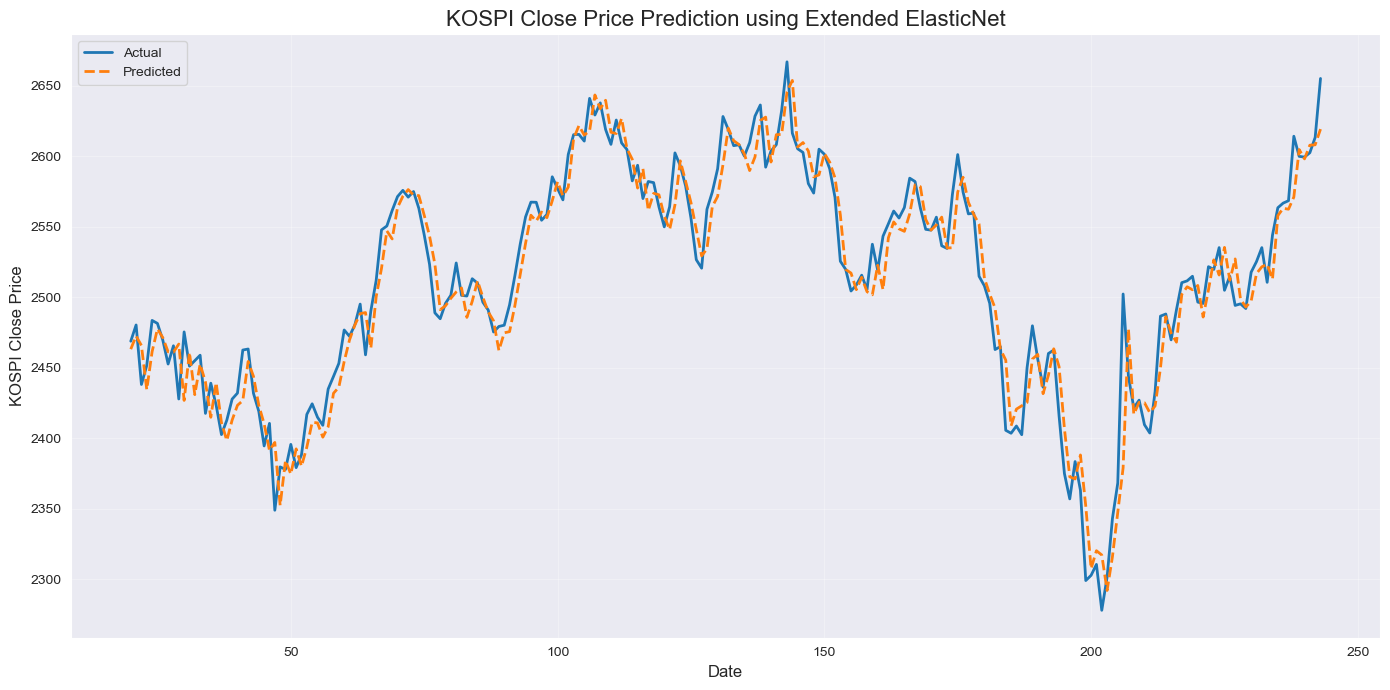

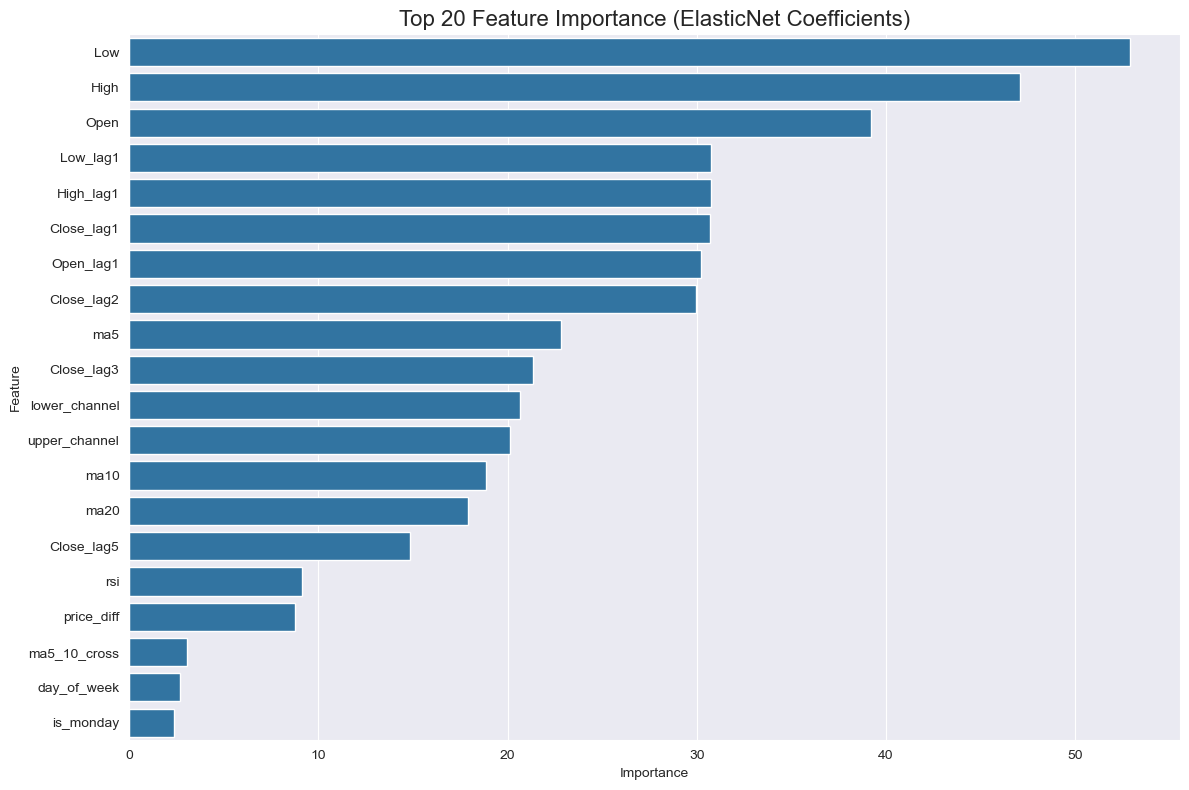


Number of non-zero coefficients: 35 out of 37

Top 10 most important features:
       Feature  Importance
1          Low   52.900114
2         High   47.095882
0         Open   39.217620
5     Low_lag1   30.749844
6    High_lag1   30.748495
7   Close_lag1   30.723242
4    Open_lag1   30.208363
9   Close_lag2   29.981245
19         ma5   22.808371
10  Close_lag3   21.321782

Comparison between Part 1 and Part 2 models:
Part 1 (ElasticNet) RMSE: 25.3232
Part 2 (Extended ElasticNet) RMSE: 20.1573
Improvement: 5.1659 (20.40%)

Part 1 (ElasticNet) R²: 0.9154
Part 2 (Extended ElasticNet) R²: 0.9350
Improvement: 0.0196 (2.14%)

Extended model evaluation metrics on test data:
model_name: Extended_ElasticNet
mse: 406.3181633361449
mae: 14.854296730952058
rmse: 20.157335224085173
r2: 0.9349522596676056


In [31]:
# Start Part 2

# Load the data (reusing code from Part 1)
def read_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')  # convert to datetime
    return df

df_train = read_data('data/kospi_train.csv')
df_test = read_data('data/kospi_test.csv')

# Part 2: Extend the model with additional predictors
# Function to create technical indicators and additional features
def create_extended_features(df):
    """
    Create extended feature set including technical indicators and derived features
    """
    df = df.copy()

    # Basic lagged features (same as Part 1)
    for col in ['Open', 'Low', 'High', 'Close', 'Volume']:
        df[f'{col}_lag1'] = df[col].shift(1)

    # Additional lags (more history)
    for col in ['Close', 'Volume']:
        for lag in [2, 3, 5]:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)

    # Price differences and returns
    df['price_diff'] = df['Close_lag1'] - df['Close_lag2']
    df['return_1d'] = df['Close_lag1'] / df['Close_lag2'] - 1

    # Volatility (standard deviation of past n days' returns)
    # Using rolling window of 5 and 10 days
    df['volatility_5d'] = df['return_1d'].rolling(window=5).std().shift(1)
    df['volatility_10d'] = df['return_1d'].rolling(window=10).std().shift(1)

    # Moving averages
    df['ma5'] = df['Close'].rolling(window=5).mean().shift(1)
    df['ma10'] = df['Close'].rolling(window=10).mean().shift(1)
    df['ma20'] = df['Close'].rolling(window=20).mean().shift(1)

    # Moving average crossovers (signals)
    df['ma5_10_cross'] = (df['ma5'] > df['ma10']).astype(int)
    df['ma10_20_cross'] = (df['ma10'] > df['ma20']).astype(int)

    # Relative Strength Index (RSI)
    try:
        df['rsi'] = ta.RSI(df['Close'].values, timeperiod=14)
        df['rsi'] = df['rsi'].shift(1)  # Shift to avoid lookahead bias
    except:
        # If talib is not available, calculate a simplified RSI
        delta = df['Close'].diff()
        gain = delta.mask(delta < 0, 0)
        loss = -delta.mask(delta > 0, 0)
        avg_gain = gain.rolling(window=14).mean()
        avg_loss = loss.rolling(window=14).mean()
        rs = avg_gain / avg_loss
        df['rsi'] = 100 - (100 / (1 + rs))
        df['rsi'] = df['rsi'].shift(1)

    # Price channels
    df['upper_channel'] = df['High'].rolling(window=10).max().shift(1)
    df['lower_channel'] = df['Low'].rolling(window=10).min().shift(1)
    df['channel_width'] = df['upper_channel'] - df['lower_channel']

    # Volume indicators
    df['volume_ma5'] = df['Volume'].rolling(window=5).mean().shift(1)
    df['volume_ratio'] = df['Volume_lag1'] / df['volume_ma5']

    # Day of week (captures weekly seasonality)
    df['day_of_week'] = df['Date'].dt.dayofweek

    # Weekend effect (Monday vs other days)
    df['is_monday'] = (df['Date'].dt.dayofweek == 0).astype(int)
    df['is_friday'] = (df['Date'].dt.dayofweek == 4).astype(int)

    # Month indicators (captures monthly seasonality)
    df['month'] = df['Date'].dt.month

    # Quarter end effect (last trading day of quarter often has higher volumes)
    df['quarter'] = df['Date'].dt.quarter
    df['month_end'] = df['Date'].dt.is_month_end.astype(int)
    df['quarter_end'] = ((df['Date'].dt.month.isin([3, 6, 9, 12])) &
                         (df['Date'].dt.is_month_end)).astype(int)

    # Drop rows with NaN values resulting from the calculations
    df = df.dropna()

    return df

# Function to prepare data for training (similar to Part 1 but adapted for extended features)
def prepare_extended_data(df, target='Close'):
    """
    Prepare the extended data for training by creating features and target
    """
    # Feature columns (exclude Date and target)
    feature_cols = [col for col in df.columns if col not in ['Date', target]]

    # Create X and y
    X = df[feature_cols]
    y = df[target]

    return X, y

# Same evaluation function from Part 1
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate the model on test data and return performance metrics
    """
    y_pred = model.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"Model: {model_name}")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

    return {
        'model_name': model_name,
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'predictions': y_pred
    }

# Create extended feature sets
print("Creating extended feature sets...")
df_train_extended = create_extended_features(df_train)
df_test_extended = create_extended_features(df_test)

# Prepare data with extended features
X_train_extended, y_train = prepare_extended_data(df_train_extended)
X_test_extended, y_test = prepare_extended_data(df_test_extended)

print(f"Shape of extended training features: {X_train_extended.shape}")
print(f"Number of features in Part 2: {X_train_extended.shape[1]}")

# Scale the features
print("Scaling features...")
scaler = StandardScaler()
X_train_extended_scaled = scaler.fit_transform(X_train_extended)
X_test_extended_scaled = scaler.transform(X_test_extended)

# Convert scaled arrays back to DataFrames to preserve column names
X_train_extended_scaled = pd.DataFrame(X_train_extended_scaled,
                                       columns=X_train_extended.columns,
                                       index=X_train_extended.index)
X_test_extended_scaled = pd.DataFrame(X_test_extended_scaled,
                                      columns=X_test_extended.columns,
                                      index=X_test_extended.index)

# Based on Part 1 results, ElasticNet was the best model
best_model_name = 'ElasticNet'  # From Part 1 results

# Initialize the extended model based on the best model from Part 1
print(f"Using {best_model_name} as the base model for extension...")
if best_model_name == 'ElasticNet':
    extended_model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=10000)
elif best_model_name == 'RandomForest':
    extended_model = RandomForestRegressor(n_estimators=100, random_state=42)
else:  # XGBoost
    extended_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the extended model
print("Training the extended model...")
extended_model.fit(X_train_extended_scaled, y_train)

# Evaluate the extended model on the test set
print("\nEvaluating the extended model on the test set...")
extended_test_results = evaluate_model(extended_model, X_test_extended_scaled, y_test, f"Extended_{best_model_name}")

# Plot actual vs predicted values
plt.figure(figsize=(14, 7))

# Get the dates from the test dataset
test_dates = df_test_extended.index

plt.plot(test_dates, y_test.values, label='Actual', linewidth=2)
plt.plot(test_dates, extended_test_results['predictions'], label='Predicted', linewidth=2, linestyle='--')
plt.title(f'KOSPI Close Price Prediction using Extended {best_model_name}', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('KOSPI Close Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'kospi_prediction_extended_{best_model_name}.png', dpi=300)
plt.show()

# For ElasticNet, analyze feature importance based on coefficients
if best_model_name == 'ElasticNet':
    # Get feature importance
    coefficients = np.abs(extended_model.coef_)
    feature_importance = pd.DataFrame({
        'Feature': X_train_extended.columns,
        'Importance': coefficients
    }).sort_values(by='Importance', ascending=False)

    # Plot top 20 feature importances
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(20)
    sns.barplot(x='Importance', y='Feature', data=top_features)
    plt.title('Top 20 Feature Importance (ElasticNet Coefficients)', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'feature_importance_extended_{best_model_name}.png', dpi=300)
    plt.show()

    # Print non-zero coefficients (ElasticNet performs feature selection)
    non_zero_features = feature_importance[feature_importance['Importance'] > 0]
    print(f"\nNumber of non-zero coefficients: {len(non_zero_features)} out of {len(feature_importance)}")
    print("\nTop 10 most important features:")
    print(non_zero_features.head(10))

# If best model is RandomForest or XGBoost, plot feature importance
elif best_model_name in ['RandomForest', 'XGBoost']:
    # Get feature importance
    if best_model_name == 'RandomForest':
        importances = extended_model.feature_importances_
    else:  # XGBoost
        importances = extended_model.feature_importances_

    # Create a DataFrame for visualization
    feature_importance = pd.DataFrame({
        'Feature': X_train_extended.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Plot top 20 feature importances
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(20)
    sns.barplot(x='Importance', y='Feature', data=top_features)
    plt.title(f'Top 20 Feature Importance (Extended {best_model_name})', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'feature_importance_extended_{best_model_name}.png', dpi=300)
    plt.show()

    print("\nTop 10 most important features:")
    print(feature_importance.head(10))

# Compare Part 1 and Part 2 results
print("\nComparison between Part 1 and Part 2 models:")
print(f"Part 1 ({best_model_name}) RMSE: 25.3232")  # From Part 1 results
print(f"Part 2 (Extended {best_model_name}) RMSE: {extended_test_results['rmse']:.4f}")
print(f"Improvement: {25.3232 - extended_test_results['rmse']:.4f} ({(1 - extended_test_results['rmse']/25.3232)*100:.2f}%)")

print(f"\nPart 1 ({best_model_name}) R²: 0.9154")  # From Part 1 results
print(f"Part 2 (Extended {best_model_name}) R²: {extended_test_results['r2']:.4f}")
print(f"Improvement: {extended_test_results['r2'] - 0.9154:.4f} ({(extended_test_results['r2']/0.9154 - 1)*100:.2f}%)")

# Print full model evaluation metrics
print("\nExtended model evaluation metrics on test data:")
for key, value in extended_test_results.items():
    if key != 'predictions':
        print(f"{key}: {value}")